# Imports

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn
seaborn.set_style('whitegrid')

from timm.models import create_model, load_checkpoint

from ecgflow import metrics as ecgflow_metrics
from ecgflow import dataloader
from ecgflow.models import mvtst
from ecgflow.evaluate import model_predict

DEVICE = 'cuda'
ECGFLOW_ROOT = Path.home()/'ecgflow'
EXP_ROOT = ECGFLOW_ROOT/'experiments'
DATA_ROOT = ECGFLOW_ROOT/'data'/'ptb-xl'

# Data inspection

The waveform data underlying the PTB-XL ECG dataset was collected with devices from Schiller AG between October 1989 and June 1996.

## `plot_ecg()`

In [3]:
def plot_ecg(wf, sharex=True, sharey=False, outpath=None):
    nrows = wf.shape[0]
    fig, axs = plt.subplots(nrows, 1, sharex=sharex, sharey=sharey,
                            figsize=(9, 6))
    for it in range(nrows):
        axs[it].plot(wf[it, :], 'b-', lw=0.5)
    if outpath:
        fig.tight_layout(pad=0, h_pad=1.08, w_pad=1.08)
        fig.savefig(outpath)

## `eval()`

In [4]:
MODEL_VARIANT = 'mvtst_base_patch50'
SEQ_SIZE = 5000
IN_CHANS = 8
INPUT_SIZE = (IN_CHANS, SEQ_SIZE)
MODEL_BEST = dataloader.MODEL_BEST

def eval(dataset_name, exp_name, split='test'):
    expdir = EXP_ROOT/dataset_name/exp_name
    print(f'Experiment dir {expdir.as_posix()}')
    checkpoint_path = expdir/MODEL_BEST
    assert checkpoint_path.exists(), print(checkpoint_path)
    outpath_base = checkpoint_path.parent/'holdout-test'
    print(f'Output {outpath_base}')
    loader = dataloader.get_dataloader(
        data_dir=DATA_ROOT.as_posix(), dataset_name=f'ecgflow/{dataset_name}', 
        split=split, input_size=INPUT_SIZE, config={}, shuffle=False)
    print(f'Dataset {dataset_name} size {len(loader.dataset)}')
    label_names = loader.dataset.classes
    num_classes = len(label_names)
    model = create_model(
        MODEL_VARIANT, in_chans=IN_CHANS, img_size=SEQ_SIZE, 
        num_classes=num_classes)
    model.to(DEVICE)
    load_checkpoint(model, checkpoint_path, use_ema=False)
    _, y_pred_prob, y_true, m = model_predict(
        model, loader, return_roc=True, num_classes=num_classes, debug=True)
    roc_tup = m['ROC'].compute()
    res, roc_list = ecgflow_metrics.multilabel_youden_metrics(
        y_true, y_pred_prob, roc_tup[0], roc_tup[1], label_arr=label_names, 
        optimal_threshold='mdpd', tag='fold10', gen_roc_list=True,
        outpath_base=outpath_base)
    return res

Dataloader

In [5]:
SEQ_SIZE = 5000
IN_CHANS = 8
INPUT_SIZE = (IN_CHANS, SEQ_SIZE)
ds_name = 'ptbxl_diag'
split = 'test'  # HOLD-OUT cohort
loader = dataloader.get_dataloader(
    data_dir=DATA_ROOT.as_posix(), dataset_name=f'ecgflow/{ds_name}',
    split=split, input_size=INPUT_SIZE, config={}, shuffle=False)
ds = loader.dataset
print(len(ds))

2158


torch.Size([8, 5000])
tensor(-0.0019) tensor(0.5245)


[(tensor(0.0070), tensor(0.4812)),
 (tensor(-0.0071), tensor(0.4148)),
 (tensor(0.0133), tensor(0.3372)),
 (tensor(0.0102), tensor(0.4627)),
 (tensor(0.0167), tensor(0.4789)),
 (tensor(-0.0368), tensor(0.6085)),
 (tensor(-0.0078), tensor(0.6546)),
 (tensor(-0.0105), tensor(0.6631))]

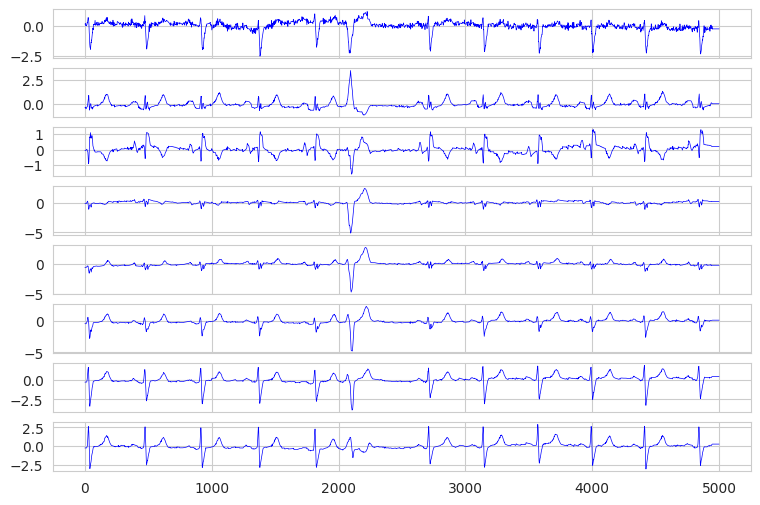

In [6]:
idx = 125
wf = ds[idx]
X = wf['X']
print(X.shape)
print(X.mean(), X.std())
display([(it.mean(), it.std()) for it in X])
plot_ecg(X)

## Verify preprocessing

In [7]:
tfxnull = lambda X: X
tfxrest = loader.dataset.transform['rest']
print(tfxrest.transforms)

[ImputeMissingWaveformValues(), Scale1D()]


In [8]:
j, idict = next(enumerate(loader))
X = idict['X']
print(X.shape)

torch.Size([128, 8, 5000])


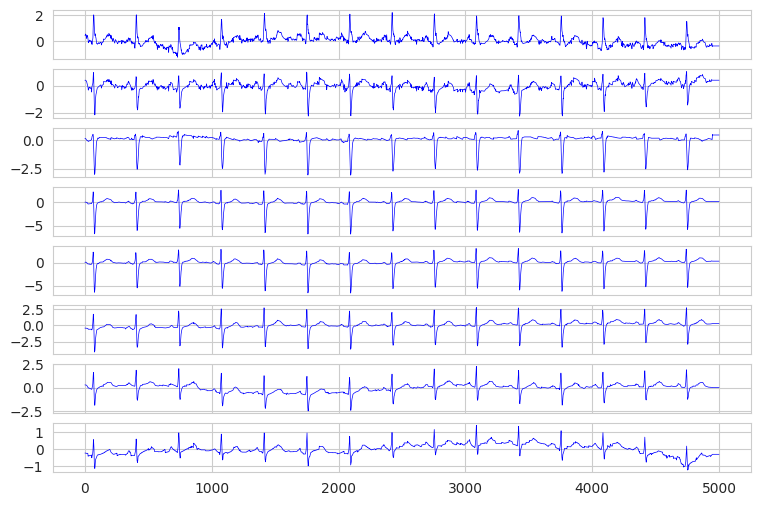

In [10]:
idx = 100
plot_ecg(X[idx])

torch.Size([8, 5000])


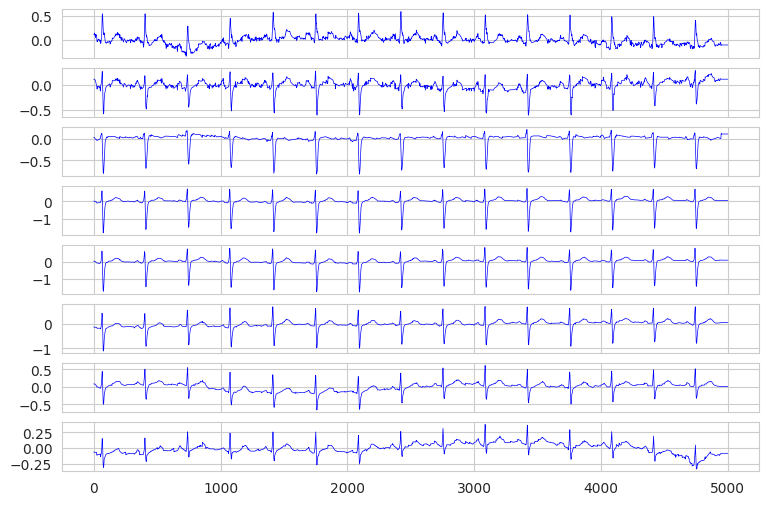

In [11]:
loader.dataset.transform['rest'] = tfxnull
idict = loader.dataset[idx]
Xd = idict['X']
print(Xd.shape)
plot_ecg(Xd)
loader.dataset.transform['rest'] = tfxrest

# PTB-XL tasks

Using PTB-XL data and predefined tasks:

 - Predefined training folds (8x) and validation fold (1x):
   - Supervised fine-tuning of SSL pretrained model 
   - Supervised de novo training of randomly initialized model
 - Predefined test fold (1x):
   - Holdout testing of above two models
      - Auto ECG diagnostic
      - Auto ECG rhythm
      - Auto ECG form

## Auto ECG Diagnostic

### SSL

In [13]:
ds_name = 'ptbxl_diag'
expname = 'mvtst-p50-d12-h8.mimic-1'
res = eval(ds_name, expname)
print(res.shape)
print('macro')
display(dict(zip(res.columns, [res[it].mean() for it in res.columns[:5]])))

Experiment dir /home/jmoody/ecgflow/experiments/ptbxl_diag/mvtst-p50-d12-h8.mimic-1
Output /home/jmoody/ecgflow/experiments/ptbxl_diag/mvtst-p50-d12-h8.mimic-1/holdout-test
Dataset ptbxl_diag size 2158
img_size, patch_size, in_chans, embed_dim 5000 50 8 800


  0%|          | 0/17 [00:00<?, ?it/s]/home/jmoody/code/ekgdl2/.venv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
100%|██████████| 17/17 [00:03<00:00,  4.75it/s]


(44, 10)
macro


{'auc': np.float64(0.9123613116689964),
 'sensitivity': np.float64(0.8961914086883719),
 'specificity': np.float64(0.8574163100936196),
 'ppv': np.float64(0.15199112333642184),
 'npv': np.float64(0.9935750228444611)}

### No SSL

In [16]:
ds_name = 'ptbxl_diag'
expname = 'mvtst-p50-d12-h8-1'
res = eval(ds_name, expname)
print(res.shape)
print('macro')
display(dict(zip(res.columns, [res[it].mean() for it in res.columns[:5]])))

Experiment dir /home/jmoody/ecgflow/experiments/ptbxl_diag/mvtst-p50-d12-h8-1
Output /home/jmoody/ecgflow/experiments/ptbxl_diag/mvtst-p50-d12-h8-1/holdout-test
Dataset ptbxl_diag size 2158
img_size, patch_size, in_chans, embed_dim 5000 50 8 800


  0%|          | 0/17 [00:00<?, ?it/s]/home/jmoody/code/ekgdl2/.venv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
100%|██████████| 17/17 [00:04<00:00,  3.68it/s]


(44, 10)
macro


{'auc': np.float64(0.8691874526025996),
 'sensitivity': np.float64(0.8856300969015468),
 'specificity': np.float64(0.8106046549298547),
 'ppv': np.float64(0.14045441718927681),
 'npv': np.float64(0.9933498313976941)}

## Auto ECG Rhythm

### SSL

In [14]:
ds_name = 'ptbxl_rhythm'
expname = 'mvtst-p50-d12-h8.mimic-1'
res = eval(ds_name, expname)
print(res.shape)
print('macro')
display(dict(zip(res.columns, [res[it].mean() for it in res.columns[:5]])))

Experiment dir /home/jmoody/ecgflow/experiments/ptbxl_rhythm/mvtst-p50-d12-h8.mimic-1
Output /home/jmoody/ecgflow/experiments/ptbxl_rhythm/mvtst-p50-d12-h8.mimic-1/holdout-test
Dataset ptbxl_rhythm size 2098
img_size, patch_size, in_chans, embed_dim 5000 50 8 800


  0%|          | 0/17 [00:00<?, ?it/s]/home/jmoody/code/ekgdl2/.venv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
100%|██████████| 17/17 [00:05<00:00,  3.32it/s]


(12, 10)
macro


{'auc': np.float64(0.9716130102977325),
 'sensitivity': np.float64(0.9537213792403539),
 'specificity': np.float64(0.9397587329149246),
 'ppv': np.float64(0.374002421986447),
 'npv': np.float64(0.9682347912454462)}

### No SSL

In [17]:
ds_name = 'ptbxl_rhythm'
expname = 'mvtst-p50-d12-h8-1'
res = eval(ds_name, expname)
print(res.shape)
print('macro')
display(dict(zip(res.columns, [res[it].mean() for it in res.columns[:5]])))

Experiment dir /home/jmoody/ecgflow/experiments/ptbxl_rhythm/mvtst-p50-d12-h8-1
Output /home/jmoody/ecgflow/experiments/ptbxl_rhythm/mvtst-p50-d12-h8-1/holdout-test
Dataset ptbxl_rhythm size 2098
img_size, patch_size, in_chans, embed_dim 5000 50 8 800


  0%|          | 0/17 [00:00<?, ?it/s]/home/jmoody/code/ekgdl2/.venv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
100%|██████████| 17/17 [00:03<00:00,  4.33it/s]


(12, 10)
macro


{'auc': np.float64(0.8605223721779662),
 'sensitivity': np.float64(0.808335746328036),
 'specificity': np.float64(0.8618352115154266),
 'ppv': np.float64(0.1816806204215574),
 'npv': np.float64(0.9523470593809146)}

## Auto ECG Form

### SSL

In [15]:
ds_name = 'ptbxl_form'
expname = 'mvtst-p50-d12-h8.mimic-1'
res = eval(ds_name, expname)
print(res.shape)
print('macro')
display(dict(zip(res.columns, [res[it].mean() for it in res.columns[:5]])))

Experiment dir /home/jmoody/ecgflow/experiments/ptbxl_form/mvtst-p50-d12-h8.mimic-1
Output /home/jmoody/ecgflow/experiments/ptbxl_form/mvtst-p50-d12-h8.mimic-1/holdout-test
Dataset ptbxl_form size 880
img_size, patch_size, in_chans, embed_dim 5000 50 8 800


  0%|          | 0/7 [00:00<?, ?it/s]/home/jmoody/code/ekgdl2/.venv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
100%|██████████| 7/7 [00:02<00:00,  2.88it/s]


(19, 10)
macro


{'auc': np.float64(0.8469219930648201),
 'sensitivity': np.float64(0.8336337146006132),
 'specificity': np.float64(0.8058383935376218),
 'ppv': np.float64(0.2352767742165413),
 'npv': np.float64(0.9809577373504617)}

### No SSL

In [18]:
ds_name = 'ptbxl_form'
expname = 'mvtst-p50-d12-h8-1'
res = eval(ds_name, expname)
print(res.shape)
print('macro')
display(dict(zip(res.columns, [res[it].mean() for it in res.columns[:5]])))

Experiment dir /home/jmoody/ecgflow/experiments/ptbxl_form/mvtst-p50-d12-h8-1
Output /home/jmoody/ecgflow/experiments/ptbxl_form/mvtst-p50-d12-h8-1/holdout-test
Dataset ptbxl_form size 880
img_size, patch_size, in_chans, embed_dim 5000 50 8 800


  0%|          | 0/7 [00:00<?, ?it/s]/home/jmoody/code/ekgdl2/.venv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
100%|██████████| 7/7 [00:02<00:00,  3.19it/s]


(19, 10)
macro


{'auc': np.float64(0.8035649726830735),
 'sensitivity': np.float64(0.799727389686986),
 'specificity': np.float64(0.750519313310322),
 'ppv': np.float64(0.18764282759681175),
 'npv': np.float64(0.9753323028864024)}